In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [33]:
df = pd.read_excel('../papers_2.xlsx')
df.head()

,Order,Paper Title,type,Citation ID,Publication Year,main cat,main cat 2,sub cat 1,sub cat 2,sub cat 3,sub cat 4,type.1
0,102.0,VirusTotal: R Client for the VirusTotal API,API,virus-total,2012.0,Defense & Tools,NaN,Third-Party Tools,NaN,NaN,NaN,NaN
1,103.0,PhishTank: Join the Fight Against Phishing,API,phishtank,2006.0,Defense & Tools,NaN,Third-Party Tools,NaN,NaN,NaN,NaN
2,135.0,"Communications APIs with AI and data for SMS, ...",API,twilioCommunicationsAPIs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,155.0,GitHub - shshnk158/Multilingual-SMS-spam-detec...,API,githubGitHubShshnk158MultilingualSMSspamdetect...,2018.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,156.0,Bengali SMS Spam Detection Dataset,API,kaggleBengaliSpam,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
df['main cat'] = df['main cat'].str.strip()
df['main cat 2'] = df['main cat 2'].str.strip()
df['sub cat 1'] = df['sub cat 1'].str.strip()
df['sub cat 2'] = df['sub cat 2'].str.strip()
df['sub cat 3'] = df['sub cat 3'].str.strip()
df['sub cat 4'] = df['sub cat 4'].str.strip()


df['main cat'] = df['main cat'].fillna('')
df['main cat 2'] = df['main cat 2'].fillna('')
df['sub cat 1'] = df['sub cat 1'].fillna('')
df['sub cat 2'] = df['sub cat 2'].fillna('')
df['sub cat 3'] = df['sub cat 3'].fillna('')
df['sub cat 4'] = df['sub cat 4'].fillna('')

df['Citation ID'] = df['Citation ID'].fillna('')


In [35]:
df['Publication Year'].value_counts()

Publication Year
2024.0    43
2023.0    25
2025.0    16
2022.0    12
2021.0     8
2020.0     8
2018.0     7
2017.0     3
2015.0     3
2019.0     3
2016.0     2
2006.0     2
2011.0     2
2013.0     1
2012.0     1
2014.0     1
2005.0     1
1988.0     1
Name: count, dtype: int64

In [36]:
min(df['Publication Year']), max(df['Publication Year'])

(1988.0, 2025.0)

In [37]:
df['main cat'] = df['main cat'].replace('Defense & Tools', 'Tools and Mobile Apps')
df['main cat 2'] = df['main cat 2'].replace('Defense & Tools', 'Tools and Mobile Apps')

In [38]:
df['main cat'].value_counts()

main cat
Detection                62
                         35
Characterization         25
User Susceptibility      19
Tools and Mobile Apps    10
User training             5
Datasets                  4
Name: count, dtype: int64

In [39]:
df['main cat 2'].value_counts()

main cat 2
                         129
Tools and Mobile Apps     13
User Susceptibility        6
Datasets                   6
User training              3
Detection                  2
Characterization           1
Name: count, dtype: int64

In [40]:
df[(df['main cat']=='Datasets')]

,Order,Paper Title,type,Citation ID,Publication Year,main cat,main cat 2,sub cat 1,sub cat 2,sub cat 3,sub cat 4,type.1
67,44.0,On SMS Phishing Tactics and Infrastructure,paper,on_phishing_tactics_nahapetyan2023sms,2024.0,Datasets,Characterization,Public Datasets,Attack Types,,,NaN
123,101.0,Smishing Dataset I: Phishing SMS Dataset from ...,paper,timko2024smishing,2024.0,Datasets,Tools and Mobile Apps,Mobile-Based Solutions,,,,NaN
129,114.0,SMS Phishing Dataset for Machine Learning and ...,paper,mishra2022sms_mendeley,2022.0,Datasets,,Public Datasets,,,,NaN
130,115.0,Creating a Live Public Short Message Service ...,paper,nus_chen2013creating,2013.0,Datasets,,Public Datasets,,,,NaN


In [41]:
df[(df['main cat 2']=='Datasets')]

,Order,Paper Title,type,Citation ID,Publication Year,main cat,main cat 2,sub cat 1,sub cat 2,sub cat 3,sub cat 4,type.1
66,40.0,Clues in Tweets: Twitter-Guided Discovery and ...,paper,twitter-clues-ccs2022-spam,2022.0,Characterization,Datasets,Public Datasets,Attack Types,,,NaN
87,64.0,SMS Scam Detection Application Based on Optica...,paper,shinde2024sms,2024.0,Detection,Datasets,Private Dataset,Machine Learning,Natural Language Processing,,NaN
88,65.0,A Persuasion-Based Prompt Learning Approach to...,paper,llm_shim2024persuasion,2024.0,Detection,Datasets,Public Datasets,Natural Language Processing,,,NaN
92,69.0,KorSmishing Explainer: A Korean-Centric LLM-Ba...,paper,expl_lee2024korsmishing,2024.0,Detection,Datasets,Natural Language Processing,Private Dataset,,,NaN
104,81.0,Contributions to the Study of SMS Spam Filteri...,paper,UCI_sms_dataset,2011.0,Detection,Datasets,Public Datasets,Machine Learning,,,NaN
105,82.0,Investigating Evasive Techniques in SMS Spam F...,paper,salman2024investigating,2024.0,Detection,Datasets,Public Datasets,Machine Learning,,,NaN


In [42]:
df['sub cat 1'].value_counts()

sub cat 1
                                  44
Machine Learning                  34
General Susceptibility Factors    18
Attack Types                      10
Deep Learning                      9
Law Enforcement & Regulatory       7
Public Datasets                    7
Mobile-Based Solutions             5
Rule-Based                         5
Third-Party Tools                  4
Psychological Techniques           3
Natural Language Processing        3
Federated Learning                 3
Demographic                        2
User Training & Awareness          1
Attack Themes                      1
Private Dataset                    1
Explainable AI                     1
Mobile-Based                       1
Hybrid                             1
Name: count, dtype: int64

In [43]:
plot_dict = {'2006-13':{}, '2014-17':{}, '2018':{}, '2019':{}, '2020':{}, '2021':{}, '2022':{}, '2023':{}, '2024':{}, '2025':{}}

for i in range(len(df)):
    year = df['Publication Year'][i]
    if year<2014:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2006-13']:
                plot_dict['2006-13'][df['main cat'][i]] += 1
            else:
                plot_dict['2006-13'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2006-13']:
                plot_dict['2006-13'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2006-13'][df['main cat 2'][i]] = 1
    
    elif year>2013 and year<2018:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2014-17']:
                plot_dict['2014-17'][df['main cat'][i]] += 1
            else:
                plot_dict['2014-17'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2014-17']:
                plot_dict['2014-17'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2014-17'][df['main cat 2'][i]] = 1
    

    elif year==2018:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2018']:
                plot_dict['2018'][df['main cat'][i]] += 1
            else:
                plot_dict['2018'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2018']:
                plot_dict['2018'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2018'][df['main cat 2'][i]] = 1

    

    elif year==2019:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2019']:
                plot_dict['2019'][df['main cat'][i]] += 1
            else:
                plot_dict['2019'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2019']:
                plot_dict['2019'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2019'][df['main cat 2'][i]] = 1


    
    elif year==2020:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2020']:
                plot_dict['2020'][df['main cat'][i]] += 1
            else:
                plot_dict['2020'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2020']:
                plot_dict['2020'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2020'][df['main cat 2'][i]] = 1

    elif year==2021:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2021']:
                plot_dict['2021'][df['main cat'][i]] += 1
            else:
                plot_dict['2021'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2021']:
                plot_dict['2021'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2021'][df['main cat 2'][i]] = 1

    
    elif year==2022:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2022']:
                plot_dict['2022'][df['main cat'][i]] += 1
            else:
                plot_dict['2022'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2022']:
                plot_dict['2022'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2022'][df['main cat 2'][i]] = 1
    

    elif year==2023:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2023']:
                plot_dict['2023'][df['main cat'][i]] += 1
            else:
                plot_dict['2023'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2023']:
                plot_dict['2023'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2023'][df['main cat 2'][i]] = 1
    

    elif year==2024:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2024']:
                plot_dict['2024'][df['main cat'][i]] += 1
            else:
                plot_dict['2024'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2024']:
                plot_dict['2024'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2024'][df['main cat 2'][i]] = 1
    

    elif year==2025:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2025']:
                plot_dict['2025'][df['main cat'][i]] += 1
            else:
                plot_dict['2025'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2025']:
                plot_dict['2025'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2025'][df['main cat 2'][i]] = 1

In [44]:
for i in plot_dict:
    for j in plot_dict[i]:
        print(j, end=', ')
    print()

Tools and Mobile Apps, Detection, Datasets, 
Detection, Tools and Mobile Apps, User Susceptibility, Characterization, 
Detection, 
Detection, Tools and Mobile Apps, 
Characterization, User Susceptibility, Detection, Tools and Mobile Apps, User training, 
Characterization, User Susceptibility, Tools and Mobile Apps, Detection, 
Detection, Characterization, User Susceptibility, Datasets, Tools and Mobile Apps, 
Tools and Mobile Apps, Detection, User Susceptibility, User training, Characterization, 
Characterization, Detection, User Susceptibility, Tools and Mobile Apps, Datasets, User training, 
User Susceptibility, Characterization, Detection, User training, 


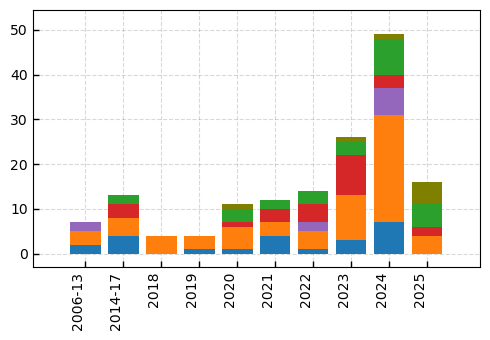

In [45]:
df_plot = pd.DataFrame.from_dict(plot_dict, orient='index').fillna(0)


custom_year_order = [
    '2006-13',
    '2014-17',
    '2018',
    '2019',
    '2020',
    '2021',
    '2022',
    '2023',
    '2024',
    '2025'
]


df_plot = df_plot.reindex(index=custom_year_order, fill_value=0)

time_periods = df_plot.index.tolist()

# Plotting
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.set_axisbelow(True)
ax.tick_params(axis='both', direction='in', length=4, width=1)

bottom = [0] * len(time_periods)


colors = {'Tools and Mobile Apps': '#1f77b4', 'Detection': '#ff7f0e', 'Characterization': '#2ca02c', 'Datasets': '#9467bd', 'User Susceptibility': '#d62728', 'User training':'olive'}

# Iterate through categories to stack bars with custom colors
for category in df_plot.columns:
    current_color = colors.get(category, 'gray') # Get color, default to 'gray' if not found
    ax.bar(time_periods, df_plot[category], label=category, bottom=bottom, color=current_color)
    # Update bottom for the next stack
    bottom = [b + val for b, val in zip(bottom, df_plot[category])]

# Moved axis limit adjustments here
x_min_orig, x_max_orig = ax.get_xlim()
y_min_orig, y_max_orig = ax.get_ylim()

padding_bottom = 3.0
padding_left = 0.5
padding_right = 0.5

ax.set_ylim(bottom=y_min_orig - padding_bottom, top=y_max_orig + padding_bottom)
ax.set_xlim(left=x_min_orig - padding_left, right=x_max_orig + padding_right)

# ax.legend(title='Category', loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2)

plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3, color='gray')
plt.grid(axis='y', linestyle='--', alpha=0.3, color='gray')
# Show the plot
plt.show()

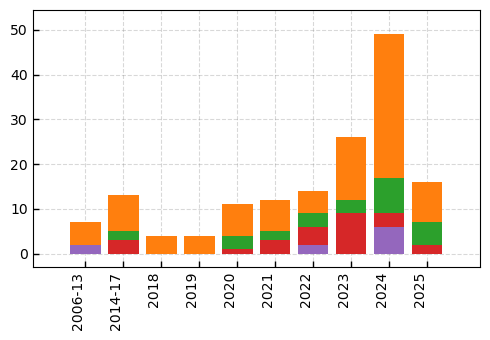

In [46]:
df_plot = pd.DataFrame.from_dict(plot_dict, orient='index').fillna(0)

custom_year_order = [
    '2006-13',
    '2014-17',
    '2018',
    '2019',
    '2020',
    '2021',
    '2022',
    '2023',
    '2024',
    '2025'
]

df_plot = df_plot.reindex(index=custom_year_order, fill_value=0)

time_periods = df_plot.index.tolist()

# Plotting
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.set_axisbelow(True)
ax.tick_params(axis='both', direction='in', length=4, width=1)

bottom = [0] * len(time_periods)

colors = {'Tools and Mobile Apps': '#1f77b4', 'Detection': '#ff7f0e', 'Characterization': '#2ca02c', 'Datasets': '#9467bd', 'User Susceptibility': '#d62728', 'User training':'olive'}

# Define categories that fall under 'Defense Landscape'
defense_categories = ['Tools and Mobile Apps', 'Detection', 'User training']

# Choose a single common color for all defense categories
# Using the original color of 'Tools and Mobile Apps' as the common defense color
common_defense_color = colors['Detection']


# Separate independent categories from defense categories
independent_categories = [col for col in df_plot.columns if col not in defense_categories]

# Define the order in which categories should be plotted for stacking
# Independent categories first, then defense categories (to group them visually)
plotting_order = independent_categories + defense_categories


# Iterate through categories based on the defined plotting_order
for category in plotting_order:
    current_color = colors.get(category, 'gray') # Get default color for non-defense categories

    # If the category is a defense category, override its color with the common defense color
    if category in defense_categories:
        current_color = common_defense_color

    ax.bar(time_periods, df_plot[category], label=category, bottom=bottom, color=current_color)
    # Update bottom for the next stack
    bottom = [b + val for b, val in zip(bottom, df_plot[category])]

# Moved axis limit adjustments here
x_min_orig, x_max_orig = ax.get_xlim()
y_min_orig, y_max_orig = ax.get_ylim()

padding_bottom = 3.0
padding_left = 0.5
padding_right = 0.5

ax.set_ylim(bottom=y_min_orig - padding_bottom, top=y_max_orig + padding_bottom)
ax.set_xlim(left=x_min_orig - padding_left, right=x_max_orig + padding_right)

# Add the legend. Matplotlib will automatically use the assigned colors for each label.
# ax.legend(title='Category', loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2)

plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3, color='gray')
plt.grid(axis='y', linestyle='--', alpha=0.3, color='gray')

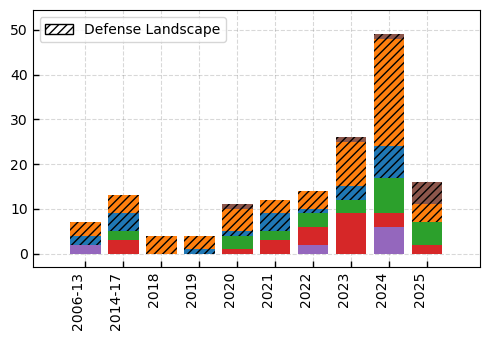

In [47]:
df_plot = pd.DataFrame.from_dict(plot_dict, orient='index').fillna(0)

custom_year_order = [
    '2006-13',
    '2014-17',
    '2018',
    '2019',
    '2020',
    '2021',
    '2022',
    '2023',
    '2024',
    '2025'
]

df_plot = df_plot.reindex(index=custom_year_order, fill_value=0)

time_periods = df_plot.index.tolist()

# Plotting
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.set_axisbelow(True)
ax.tick_params(axis='both', direction='in', length=4, width=1)

bottom = [0] * len(time_periods)

colors = {'Tools and Mobile Apps': '#1f77b4', 'Detection': '#ff7f0e', 'Characterization': '#2ca02c', 'Datasets': '#9467bd', 'User Susceptibility': '#d62728', 'User training':'#8c564b'}

# Define categories that fall under 'Defense Landscape'
defense_categories = ['Tools and Mobile Apps', 'Detection', 'User training']

# Separate independent categories from defense categories
independent_categories = [col for col in df_plot.columns if col not in defense_categories]

# Define the order in which categories should be plotted for stacking
# Here, independent categories are plotted first, then defense categories
plotting_order = independent_categories + defense_categories


# Initialize legend handles and labels, now only for 'Defense Landscape'
legend_handles = []
legend_labels = []
defense_landscape_added_to_legend = False

# Iterate through categories based on the new plotting_order
for category in plotting_order:
    current_color = colors.get(category, 'gray')
    hatch_pattern = '////' if category in defense_categories else None # Using 'xxxx' for denser stripes

    # Plot the bar
    ax.bar(time_periods, df_plot[category], bottom=bottom, color=current_color, hatch=hatch_pattern)

    # Update bottom for the next stack
    bottom = [b + val for b, val in zip(bottom, df_plot[category])]

    # Only add the 'Defense Landscape' proxy to the legend once
    if category in defense_categories and not defense_landscape_added_to_legend:
        # Set facecolor to 'none' to make the patch transparent, showing only stripes
        legend_handles.append(mpatches.Patch(facecolor='none', hatch='////', edgecolor='black')) # Ensure hatch matches
        legend_labels.append('Defense Landscape')
        defense_landscape_added_to_legend = True

# Moved axis limit adjustments here
x_min_orig, x_max_orig = ax.get_xlim()
y_min_orig, y_max_orig = ax.get_ylim()

padding_bottom = 3.0
padding_left = 0.5
padding_right = 0.5

ax.set_ylim(bottom=y_min_orig - padding_bottom, top=y_max_orig + padding_bottom)
ax.set_xlim(left=x_min_orig - padding_left, right=x_max_orig + padding_right)

# Add the legend using only the 'Defense Landscape' handles and labels
ax.legend(handles=legend_handles, labels=legend_labels, title='', loc='best') # 'best' typically finds a good spot

plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3, color='gray')
plt.grid(axis='y', linestyle='--', alpha=0.3, color='gray')

Citation generation bibtex style

In [48]:
selected_cat_citation = {}
for i in list(df['main cat'].value_counts().keys()):
    selected_cat_citation[i] = []
selected_cat_citation

{'Detection': [],
 '': [],
 'Characterization': [],
 'User Susceptibility': [],
 'Tools and Mobile Apps': [],
 'User training': [],
 'Datasets': []}

In [49]:
#a paper can have multiple categories like dataset + detection

for i in range(len(df)):
    if df['main cat'][i] and df['Citation ID'][i]:
        selected_cat_citation[df['main cat'][i]].append(df['Citation ID'][i])
    if df['main cat 2'][i] and df['Citation ID'][i]:
        selected_cat_citation[df['main cat 2'][i]].append(df['Citation ID'][i])

In [50]:
for i in selected_cat_citation:
    print(len(selected_cat_citation[i]))

64
0
26
25
23
8
10


In [51]:
'\\raisebox{0.4ex}{\\colorbox[HTML]{' + colors['Detection'][1:] + '}{\\color[HTML]{' + colors['Detection'][1:] + '}\\rule{0.1cm}{0.1cm}}} \\textbf{Detection ('+str(len(selected_cat_citation['Detection']))+' papers)} \\cite{' + ', '.join(selected_cat_citation['Detection']) + '}'

'\\raisebox{0.4ex}{\\colorbox[HTML]{ff7f0e}{\\color[HTML]{ff7f0e}\\rule{0.1cm}{0.1cm}}} \\textbf{Detection (64 papers)} \\cite{goel2018smishing, jain2022content, aleroud2017phishing, gupta_threatgpt, roy2024chatbots, al2024advancements, pritom_25_codaspy_smishviz, mishra2019content, ghourabi2020hybrid, sonowal2020detecting, smdetector_ghourabi, njuguna2021model, ulfath2022detecting, spam_filtering_cnn_lstm_hossain, smsprotect_akande, karhani_phishing_2023, dsmish_mishra_2023, shanto2023federated, sidhpura2023_fedspam:, seo2024device, anh2024federated, hapase2024telecommunication, rose2024next_federated, mehmood2024enhancing, shinde2024sms, llm_shim2024persuasion, uddin2024explainabledetector, wangcan, samad2023smishguard, expl_lee2024korsmishing, vats2024federated, mahmud2024enhancing, NIPS2017_SHAP, ribeiro2016should, shendkar2024enhancing, mohite2024interpretable, kohilan2023machine, goel2024machine, chithambaramani2024sms, enron_vangelis2006spam, british_sms_dataset2011, UCI_sms_dat

In [52]:
len(selected_cat_citation['Detection'])

64

In [53]:
'\\raisebox{0.4ex}{\\colorbox[HTML]{' + colors['Tools and Mobile Apps'][1:] + '}{\\color[HTML]{' + colors['Tools and Mobile Apps'][1:] + '}\\rule{0.1cm}{0.1cm}}} \\textbf{Tools \& Mobile Apps ('+str(len(selected_cat_citation['Tools and Mobile Apps']))+' papers)} \\cite{' + ', '.join(selected_cat_citation['Tools and Mobile Apps']) + '}'

'\\raisebox{0.4ex}{\\colorbox[HTML]{1f77b4}{\\color[HTML]{1f77b4}\\rule{0.1cm}{0.1cm}}} \\textbf{Tools \\& Mobile Apps (23 papers)} \\cite{virus-total, phishtank, commerial_anti_smishing_timko_2023, aleroud2017phishing, al2024advancements, siadati2017mind, blancaflor2021let, liu2021detecting, shahriar2015mobile, njuguna2021model, smsprotect_akande, mishra2019mit, kanaoka2023beyond, timko2024smishing, wang2024verisms, zielinski2024evolving_law, bappy2024conchain_attackresilient, 2022blockchain_csm_mir_xu, sajid_2021_soda, tsunoda2024demonstrating, haizam2024analysing, gupta2016exploiting, Mir2020_COVID_themed_threats_ISI}'

In [54]:
len(selected_cat_citation['Tools and Mobile Apps'])

23

In [55]:
'\\raisebox{0.4ex}{\\colorbox[HTML]{' + colors['User Susceptibility'][1:] + '}{\\color[HTML]{' + colors['User Susceptibility'][1:] + '}\\rule{0.1cm}{0.1cm}}} \\textbf{User Susceptibility ('+str(len(selected_cat_citation['User Susceptibility']))+' papers)} \\cite{' + ', '.join(selected_cat_citation['User Susceptibility']) + '}'

'\\raisebox{0.4ex}{\\colorbox[HTML]{d62728}{\\color[HTML]{d62728}\\rule{0.1cm}{0.1cm}}} \\textbf{User Susceptibility (25 papers)} \\cite{lutfor_23_codaspy_users_smished, ribeiro2024factors, tabassum2024drives_uncc, sarno2024gets_users, clasen2021friend, edwards2023smishing, alabdan2020phishing, blancaflor2023case, faklaris2023preliminary, siddiqi2022study, siadati2017mind, blancaflor2021let, kumarasinghe2023user, yeboah2014phishing, sugunaraj2022cyber_laws, katsarakes2024users, yan2021awareness, timko2023quantitative, timkounderstanding, yoro2023evidence, bach2022targets, multi_modal_neupane, yoro2023assessing, Longtchi_2025_Phsychological_tactics, ic3}'

In [56]:
len(selected_cat_citation['User Susceptibility'])

25

In [57]:
'\\raisebox{0.4ex}{\\colorbox[HTML]{' + colors['Datasets'][1:] + '}{\\color[HTML]{' + colors['Datasets'][1:] + '}\\rule{0.1cm}{0.1cm}}}  \\textbf{Datasets('+str(len(selected_cat_citation['Datasets']))+' papers)} \\cite{' + ', '.join(selected_cat_citation['Datasets']) + '}'

'\\raisebox{0.4ex}{\\colorbox[HTML]{9467bd}{\\color[HTML]{9467bd}\\rule{0.1cm}{0.1cm}}}  \\textbf{Datasets(10 papers)} \\cite{twitter-clues-ccs2022-spam, on_phishing_tactics_nahapetyan2023sms, shinde2024sms, llm_shim2024persuasion, expl_lee2024korsmishing, UCI_sms_dataset, salman2024investigating, timko2024smishing, mishra2022sms_mendeley, nus_chen2013creating}'

In [58]:
len(selected_cat_citation['Datasets'])

10

In [59]:
'\\raisebox{0.4ex}{\\colorbox[HTML]{' + colors['Characterization'][1:] + '}{\\color[HTML]{' + colors['Characterization'][1:] + '}\\rule{0.1cm}{0.1cm}}} \\textbf{Attack Characterization('+str(len(selected_cat_citation['Characterization']))+' papers)} \\cite{' + ', '.join(selected_cat_citation['Characterization']) + '}'

'\\raisebox{0.4ex}{\\colorbox[HTML]{2ca02c}{\\color[HTML]{2ca02c}\\rule{0.1cm}{0.1cm}}} \\textbf{Attack Characterization(26 papers)} \\cite{shibli2024abusegpt, clasen2021friend, alabdan2020phishing, XuPIEEE2024, siddiqi2022study, Longtchi_2025_Phsychological_tactics, liu2021detecting, pritom_25_codaspy_smishviz, shahriar2015mobile, twitter-clues-ccs2022-spam, on_phishing_tactics_nahapetyan2023sms, montanez2022cyberkillchain, montanez2024Quantifying, tsunoda2024demonstrating, haizam2024analysing, gupta2016exploiting, Mir2020_COVID_themed_threats_ISI, Mir2020_data_COVID_websites_ISI, covid-themed-scams-asiaCCS2023, mia2025_warthemed_websites_TPS, agarwal2025hey, nahapetyanposter_2023, FTC_latest_report_2025, apwg_phishing_trend2024, ahnlab2023, FTC_loss_stat}'

In [60]:
len(selected_cat_citation['Characterization'])

26

In [61]:
'\\raisebox{0.4ex}{\\colorbox[HTML]{' + colors['User training'][1:] + '}{\\color[HTML]{' + colors['User training'][1:] + '}\\rule{0.1cm}{0.1cm}}} \\textbf{User Training and Regulation('+str(len(selected_cat_citation['User training']))+' papers)} \\cite{' + ', '.join(selected_cat_citation['User training']) + '}'

'\\raisebox{0.4ex}{\\colorbox[HTML]{8c564b}{\\color[HTML]{8c564b}\\rule{0.1cm}{0.1cm}}} \\textbf{User Training and Regulation(8 papers)} \\cite{faklaris2023preliminary, zielinski2024evolving_law, FTC_latest_report_2025, gdpr-walker, idtexpressDataPrivacy, yotpoNeedKnow, gdprlocalEssentialGuide, caCCPAEnforcement}'

In [62]:
len(selected_cat_citation['User training'])

8